В работе используется датасет Food Demand Forecasting, исходно имеющий недельную гранулярность.
Для целей курсовой строится агрегированный ряд компании и его ежедневизированная proxy-версия.
Сравниваются статистические и ML-методы детекции аномалий, а качество оценивается по ручной и/или синтетической разметке.

In [3]:
#импортируем библиотеки 
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

from statsmodels.tsa.seasonal import STL

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as e:
    PROPHET_AVAILABLE = False
    print(f"Prophet недоступен: {e}")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

Prophet недоступен: No module named 'prophet'


In [11]:
# чтение дата сета 

data_dir = os.path.join(os.path.dirname(os.path.abspath("work.ipynb")), "course paper")

train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))
fulfilment = pd.read_csv(os.path.join(data_dir, "fulfilment_center_info.csv"))
meal_info = pd.read_csv(os.path.join(data_dir, "meal_info.csv"))

print("train:", train.shape)
print("test:", test.shape)
print("fulfilment:", fulfilment.shape)
print("meal_info:", meal_info.shape)
train.head()

train: (456548, 9)
test: (32573, 8)
fulfilment: (77, 5)
meal_info: (51, 3)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


Поскольку Kaggle-набор даёт недельный индекс week, а не календарную дату, в preprocess() мы строим synthetic временную ось ds, затем агрегируем данные по неделям на уровне всей компании. Если нужен именно график “продаж”, а не заказов, можно использовать proxy-выручку num_orders * checkout_price; это инженерное приближение, потому что отдельного поля POS-выручки в наборе нет. Наличие колонок num_orders и checkout_price видно в превью датасета. 

In [12]:
RUS_DOW = {0: "Пн", 1: "Вт", 2: "Ср", 3: "Чт", 4: "Пт", 5: "Сб", 6: "Вс"}

def weekly_to_daily_proxy(weekly_df, y_col="y", random_state=42):
    """
    Переводит недельный ряд в synthetic daily proxy.
    Сумма по 7 дням в каждой неделе сохраняется.
    """
    rng = np.random.default_rng(random_state)
    base_weights = np.array([0.11, 0.12, 0.13, 0.14, 0.16, 0.19, 0.15], dtype=float)
    base_weights /= base_weights.sum()

    rows = []
    for _, row in weekly_df.iterrows():
        jitter = np.clip(rng.normal(loc=1.0, scale=0.03, size=7), 0.85, 1.15)
        weights = base_weights * jitter
        weights /= weights.sum()

        for i in range(7):
            rows.append({
                "ds": row["ds"] + pd.Timedelta(days=i),
                "week": int(row["week"]),
                "y": float(row[y_col] * weights[i])
            })

    daily = pd.DataFrame(rows).sort_values("ds").reset_index(drop=True)
    daily["dow_num"] = daily["ds"].dt.dayofweek
    daily["dow"] = daily["dow_num"].map(RUS_DOW)
    return daily

def preprocess(train_df, target="revenue_proxy", make_daily_proxy=True, random_state=42):
    df = train_df.copy()

    # proxy-выручка
    df["revenue_proxy"] = df["num_orders"] * df["checkout_price"]

    # агрегирование уровня "вся компания за неделю"
    weekly = (
        df.groupby("week", as_index=False)
          .agg(
              num_orders=("num_orders", "sum"),
              revenue_proxy=("revenue_proxy", "sum"),
              checkout_price_mean=("checkout_price", "mean"),
              promo_share=("emailer_for_promotion", "mean"),
              homepage_share=("homepage_featured", "mean")
          )
    )

    # synthetic временная ось
    base_date = pd.Timestamp("2018-01-01")
    weekly["ds"] = base_date + pd.to_timedelta(
        (weekly["week"] - weekly["week"].min()) * 7, unit="D"
    )
    weekly = weekly.sort_values("ds")

    # заполняем возможные пропуски недель
    full_range = pd.date_range(weekly["ds"].min(), weekly["ds"].max(), freq="W-MON")
    weekly = (
        weekly.set_index("ds")
              .reindex(full_range)
              .rename_axis("ds")
              .reset_index()
    )
    weekly["week"] = np.arange(1, len(weekly) + 1)

    for col in ["num_orders", "revenue_proxy", "checkout_price_mean", "promo_share", "homepage_share"]:
        weekly[col] = weekly[col].interpolate(limit_direction="both")

    weekly["y"] = weekly[target]
    weekly["granularity"] = "weekly"

    if not make_daily_proxy:
        return weekly

    daily = weekly_to_daily_proxy(
        weekly[["ds", "week", "y"]],
        y_col="y",
        random_state=random_state
    )

    daily = daily.merge(
        weekly[["week", "num_orders", "revenue_proxy", "checkout_price_mean", "promo_share", "homepage_share"]],
        on="week",
        how="left"
    )

    # защитный шаг: делаем непрерывный дневной индекс и заполняем пропуски
    daily = daily.set_index("ds").asfreq("D")
    daily["week"] = daily["week"].ffill().bfill()
    for col in ["y", "num_orders", "revenue_proxy", "checkout_price_mean", "promo_share", "homepage_share"]:
        daily[col] = daily[col].interpolate(limit_direction="both")

    daily = daily.reset_index()
    daily["dow_num"] = daily["ds"].dt.dayofweek
    daily["dow"] = daily["dow_num"].map(RUS_DOW)
    daily["granularity"] = "daily_proxy"
    return daily, weekly

data_daily, data_weekly = preprocess(
    train,
    target="revenue_proxy",   # можно заменить на num_orders
    make_daily_proxy=True,
    random_state=RANDOM_STATE
)

print(data_daily.shape, data_weekly.shape)
display(data_daily.head())


(1015, 11) (145, 9)


,ds,week,y,dow_num,dow,num_orders,revenue_proxy,checkout_price_mean,promo_share,homepage_share,granularity
0,2018-01-01,1,2.455299e+07,0,Пн,792261,2.185165e+08,330.530205,0.122177,0.141684,daily_proxy
1,2018-01-02,1,2.571433e+07,1,Вт,792261,2.185165e+08,330.530205,0.122177,0.141684,daily_proxy
2,2018-01-03,1,2.940167e+07,2,Ср,792261,2.185165e+08,330.530205,0.122177,0.141684,daily_proxy
3,2018-01-04,1,3.183995e+07,3,Чт,792261,2.185165e+08,330.530205,0.122177,0.141684,daily_proxy
4,2018-01-05,1,3.331851e+07,4,Пт,792261,2.185165e+08,330.530205,0.122177,0.141684,daily_proxy


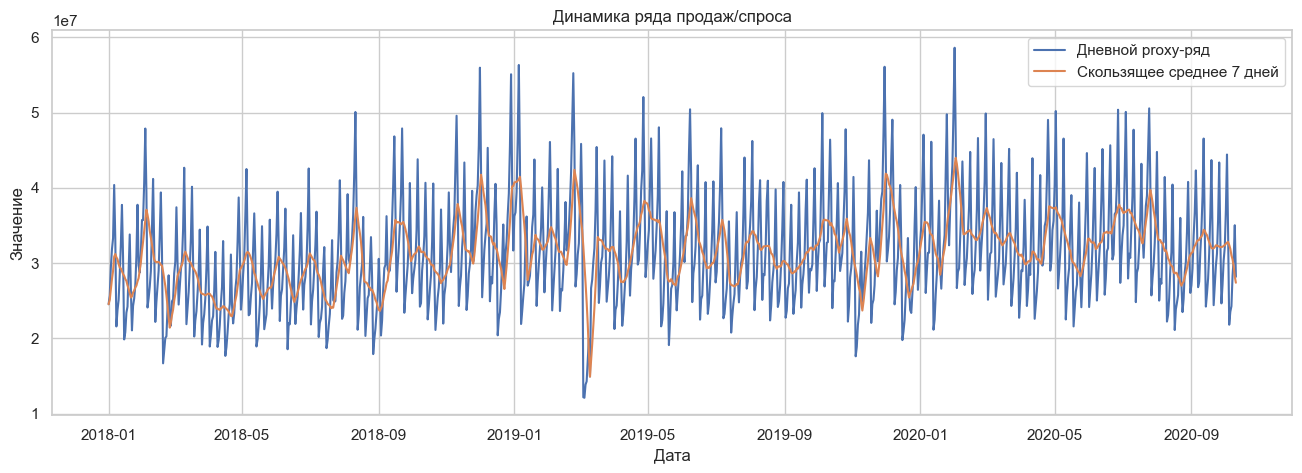

In [13]:
# Линейный график ряда + сглаживание
plt.figure(figsize=(16, 5))
plt.plot(data_daily["ds"], data_daily["y"], label="Дневной proxy-ряд")
plt.plot(
    data_daily["ds"],
    data_daily["y"].rolling(7, min_periods=1).mean(),
    label="Скользящее среднее 7 дней"
)
plt.title("Динамика ряда продаж/спроса")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.show()


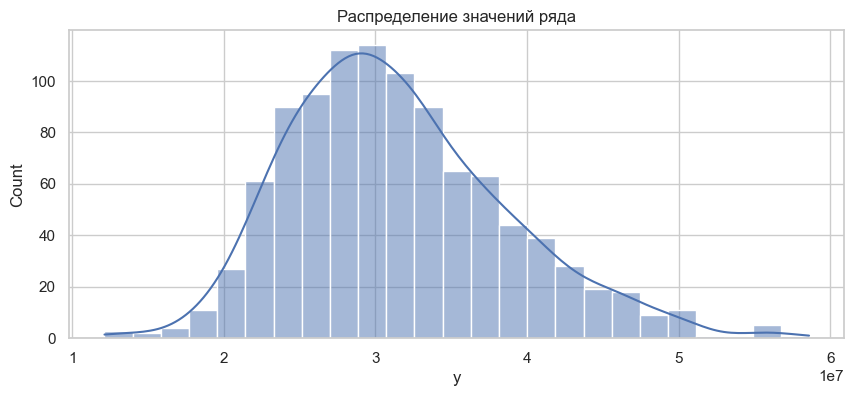

In [14]:
# Распределение
plt.figure(figsize=(10, 4))
sns.histplot(data_daily["y"], kde=True)
plt.title("Распределение значений ряда")
plt.xlabel("y")
plt.show()


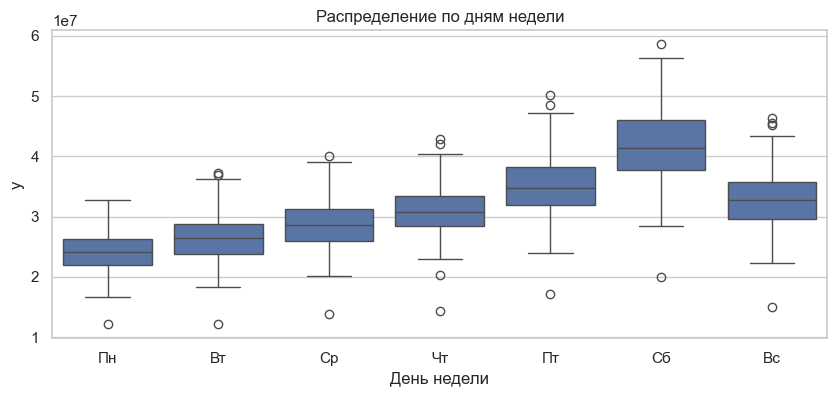

,mean,median,std,count
dow,,,,
Пн,2.426287e+07,2.418710e+07,3.495266e+06,145
Вт,2.644177e+07,2.641261e+07,3.883653e+06,145
Ср,2.858702e+07,2.855402e+07,4.167778e+06,145
Чт,3.082477e+07,3.075124e+07,4.308374e+06,145
Пт,3.516838e+07,3.479577e+07,5.131770e+06,145
Сб,4.192116e+07,4.145092e+07,6.075695e+06,145
Вс,3.295108e+07,3.278726e+07,4.847351e+06,145


In [15]:
# Профиль по дням недели
dow_order = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

plt.figure(figsize=(10, 4))
sns.boxplot(data=data_daily, x="dow", y="y", order=dow_order)
plt.title("Распределение по дням недели")
plt.xlabel("День недели")
plt.ylabel("y")
plt.show()

display(
    data_daily.groupby("dow", observed=False)["y"]
              .agg(["mean", "median", "std", "count"])
              .reindex(dow_order)
)


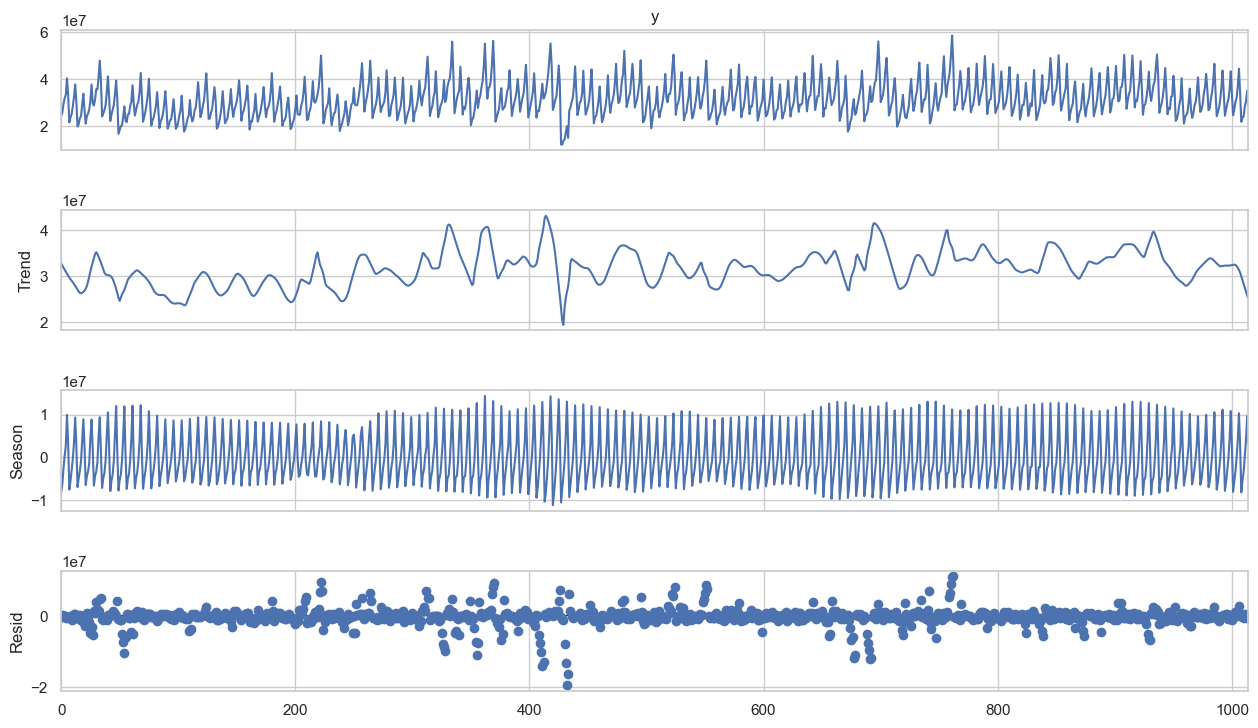

In [16]:
def add_stl(df, period=7, robust=True):
    out = df.copy()
    stl = STL(out["y"], period=period, robust=robust)
    res = stl.fit()
    out["trend"] = res.trend
    out["seasonal"] = res.seasonal
    out["resid"] = res.resid
    return out, res

data_daily, stl_result = add_stl(data_daily, period=7)
fig = stl_result.plot()
fig.set_size_inches(14, 8)
plt.show()


## Правила разметки аномалий

Аномалия = день, когда значение ряда резко отклоняется от локального контекста:
- резкий пик без поддержки соседних дней;
- резкий провал относительно соседних дней;
- нетипичное значение для данного дня недели;
- краткий выброс, не объясняемый сезонностью.

Не считаются аномалиями:
- плавный тренд;
- регулярные выходные пики;
- повторяющаяся сезонность;
- умеренные колебания внутри обычного диапазона.

Метка:
- `1` — аномалия;
- `0` — норма.


In [17]:
manual_labels = pd.DataFrame({
    "ds": pd.to_datetime([
        "2018-02-16",
        "2018-04-07",
        "2018-05-11"
    ]),
    "label_manual": [1, 1, 0],
    "comment": [
        "Подозрительный пик относительно соседних дней",
        "Резкий провал в день с ожидаемо высоким спросом",
        "Нормальная сезонность выходного дня"
    ]
})

data_daily = data_daily.merge(manual_labels, on="ds", how="left")
data_daily["label_manual"] = data_daily["label_manual"].fillna(0).astype(int)

display(data_daily.loc[data_daily["comment"].notna(), ["ds", "y", "label_manual", "comment"]])


,ds,y,label_manual,comment
46,2018-02-16,3.381425e+07,1,Подозрительный пик относительно соседних дней
96,2018-04-07,3.150106e+07,1,Резкий провал в день с ожидаемо высоким спросом
130,2018-05-11,3.178592e+07,0,Нормальная сезонность выходного дня
